# Data Preprocessing

### 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [3]:
from pathlib import Path

pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
TAXONOMY_PATH = DATA_DIR / "label_taxonomy.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission_random_guess.csv"

In [4]:
# Verify files exist
required_paths = [TRAIN_PATH, TEST_PATH, TAXONOMY_PATH]
missing_files = [str(p) for p in required_paths if not p.exists()]

if missing_files:
    print("Missing required files:")
    for file in missing_files:
        print("-", file)
    raise FileNotFoundError("Please add the dataset CSV files to the data folder.")

# Load data with tab separator
train_df = pd.read_csv(TRAIN_PATH, sep="\t")
test_df = pd.read_csv(TEST_PATH, sep="\t")
taxonomy_df = pd.read_csv(TAXONOMY_PATH, sep="\t")

# Load sample submission if it exists
if SAMPLE_SUBMISSION_PATH.exists():
    sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
else:
    sample_submission = None

print("\n✓ Data loaded successfully!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Taxonomy shape: {taxonomy_df.shape}")
print(f"Sample submission shape: {sample_submission.shape if sample_submission is not None else 'N/A'}")

# Display first few rows
print("\nFirst few rows of train data:")
display(train_df.head())

print("\nFirst few rows of test data:")
display(test_df.head())

print("\nLabel taxonomy:")
display(taxonomy_df.head())

print("\n Sample submission:")
display(sample_submission.head())


✓ Data loaded successfully!
Train shape: (139156, 3)
Test shape: (34790, 2)
Taxonomy shape: (39, 2)
Sample submission shape: (34790, 2)

First few rows of train data:


,id,abstract,label_id
0,95829,"Project-based learning plays a crucial role in computing education. However, its open-ended nature makes tracking project development and assessing success ...",14
1,73195,Edge computing is a distributed computing paradigm that brings computation\nand data storage closer to the user's geographical location to improve respons...,10
2,22319,"In today's computing environment, where Artificial Intelligence (AI) and data\nprocessing are moving toward the Internet of Things (IoT) and Edge computin...",3
3,76837,"Diffusion pipelines, renowned for their powerful visual generation capabilities, have seen widespread adoption in generative vision tasks (e.g., text-to-ima...",10
4,159150,Convolutional neural networks (CNNs) are emerging as powerful tools for image\nprocessing in important commercial applications. We focus on the important\...,30



First few rows of test data:


,id,abstract
0,173148,"Non-Boolean computing based on emerging post-CMOS technologies can\npotentially pave the way for low-power neural computing platforms. However,\nexisting ..."
1,29098,"Combining the properties of monovariate internal functions as proposed in\nKolmogorov superimposition theorem, in tandem with the bounds wielded by the\nm..."
2,28211,"We study the problem of unsupervised discovery and segmentation of object\nparts, which, as an intermediate local representation, are capable of finding\n..."
3,136101,We revisit the fundamental problem of I/O-efficiently computing $r$-way\nseparators on planar graphs. An $r$-way separator divides a planar graph with\n$N...
4,97133,"Through a mixed-method analysis of data from Scratch, we examine how novices\nlearn to program with simple data structures by using community-produced\nle..."



Label taxonomy:


,label_id,category
0,0,cs.DS
1,1,cs.CC
2,2,cs.CR
3,3,cs.PF
4,4,cs.CV



 Sample submission:


,id,label_id
0,173148,38
1,29098,28
2,28211,14
3,136101,7
4,97133,20


In [5]:
# Check for missing values
print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
print(f"Missing values in test: {test_df.isnull().sum().sum()}")


Missing values in train: 0
Missing values in test: 0



Number of unique labels: 39

Top 10 most frequent labels:
  Label 6 (cs.SE): 8,000 samples (5.7%)
  Label 5 (cs.LG): 8,000 samples (5.7%)
  Label 8 (cs.AI): 8,000 samples (5.7%)
  Label 18 (cs.CL): 8,000 samples (5.7%)
  Label 12 (cs.NI): 8,000 samples (5.7%)
  Label 23 (cs.RO): 8,000 samples (5.7%)
  Label 2 (cs.CR): 8,000 samples (5.7%)
  Label 4 (cs.CV): 8,000 samples (5.7%)
  Label 0 (cs.DS): 7,773 samples (5.6%)
  Label 14 (cs.HC): 7,635 samples (5.5%)


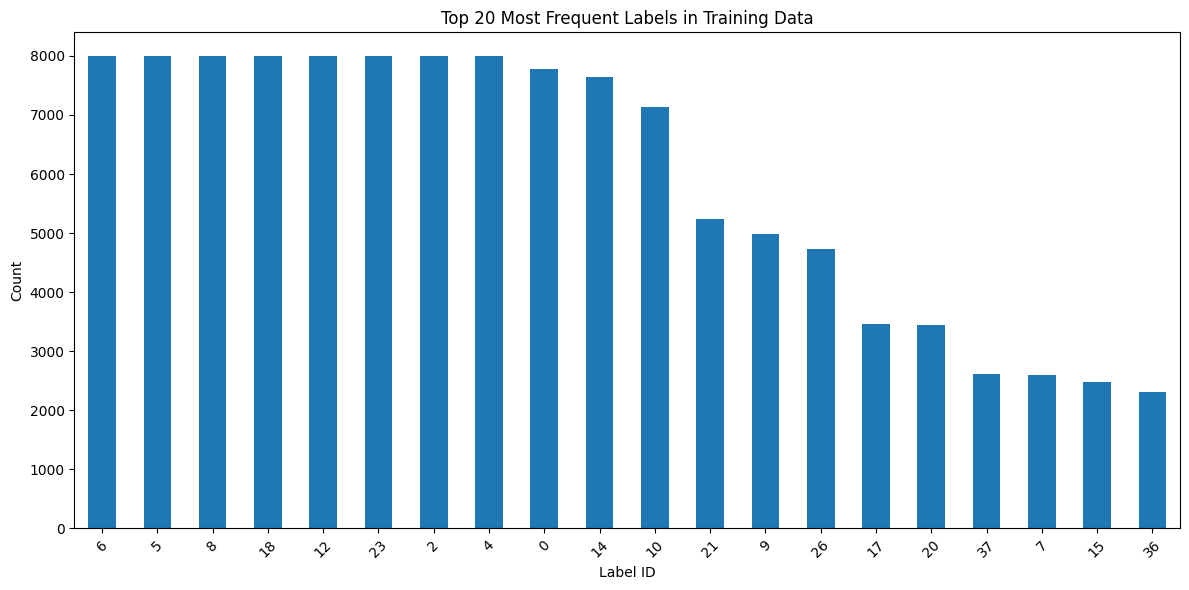

In [6]:
# Check class distribution
print(f"\nNumber of unique labels: {train_df['label_id'].nunique()}")
print("\nTop 10 most frequent labels:")
label_counts = train_df['label_id'].value_counts()
for label, count in label_counts.head(10).items():
    # Get category name from taxonomy
    category = taxonomy_df[taxonomy_df['label_id'] == label]['category'].values[0] if label in taxonomy_df['label_id'].values else "Unknown"
    percentage = (count / len(train_df)) * 100
    print(f"  Label {label} ({category}): {count:,} samples ({percentage:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(12, 6))
label_counts.head(20).plot(kind='bar')
plt.title('Top 20 Most Frequent Labels in Training Data')
plt.xlabel('Label ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DATA_DIR / 'class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 2. Text Cleaning

In [11]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

class TextPreprocessor:
    def __init__(self, use_stemming=False, use_lemmatization=True, remove_stopwords=True):
        self.use_stemming = use_stemming
        self.use_lemmatization = use_lemmatization
        self.remove_stopwords = remove_stopwords
        
        if use_stemming:
            self.stemmer = PorterStemmer()
        if use_lemmatization:
            self.lemmatizer = WordNetLemmatizer()
        if remove_stopwords:
            self.stop_words = set(stopwords.words('english'))
    
    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        
        # 1. Lowercase
        text = text.lower()
        
        # 2. Remove LaTeX math expressions: $...$ and \[...\]
        text = re.sub(r'\$.*?\$', '', text)
        text = re.sub(r'\\\[.*?\\\]', '', text, flags=re.DOTALL)
        
        # 3. Remove LaTeX commands (e.g., \frac, \text, \alpha)
        # We remove the command but try to keep the text inside curly braces if it exists
        # e.g., \textbf{hello} -> hello
        text = re.sub(r'\\[a-zA-Z]+\{(.*?)\}', r'\1', text)
        # Remove any remaining standalone commands like \alpha or \frac without braces
        text = re.sub(r'\\[a-zA-Z]+', '', text)
        
        # 4. Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        
        # 5. Remove citations like [1], [2,3]
        text = re.sub(r'\[[0-9, ]+\]', '', text)
        
        # 6. Keep letters, numbers, hyphens, and underscores
        # This addresses the "3d" and "real-world" issues from your chat
        text = re.sub(r'[^a-z0-9\-_ ]', ' ', text)
        
        # 7. Cleanup whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def get_wordnet_pos(self, word):
        """
        Map POS tag to first character lemmatize() accepts
        """
        if not self.use_lemmatization:
            return 'n'  # Default to noun if not using lemmatization
        
        # This is a simplified version; for better results, you'd use pos_tag
        # but that requires tokenization first
        return 'n'  # Default to noun for simplicity
    
    def preprocess(self, text):
        """Full preprocessing pipeline"""
        # Clean text
        text = self.clean_text(text)
        
        # Tokenize
        words = text.split()
        
        # 7. FILTER: Remove stopwords AND all single letters (length > 1)
        # This ensures 'e' and 'g' are removed even if stopwords are being processed
        if self.remove_stopwords:
            words = [w for w in words if w not in self.stop_words and len(w) > 1]
        else:
            words = [w for w in words if len(w) > 1]
        
        # Apply stemming or lemmatization
        if self.use_stemming:
            words = [self.stemmer.stem(w) for w in words]
        elif self.use_lemmatization:
            words = [self.lemmatizer.lemmatize(w) for w in words]
        
        return ' '.join(words)

# Apply preprocessing to abstracts
preprocessor = TextPreprocessor(use_lemmatization=True, remove_stopwords=True)

train_df['cleaned_abstract'] = train_df['abstract'].apply(preprocessor.preprocess)
test_df['cleaned_abstract'] = test_df['abstract'].apply(preprocessor.preprocess)

print("Sample before preprocessing:")
print(train_df['abstract'].iloc[0][:200])
print("\nSample after preprocessing:")
print(train_df['cleaned_abstract'].iloc[0][:200])
display(train_df.head(100)[['abstract', 'cleaned_abstract']])

[nltk_data] Downloading package stopwords to C:\Users\esther.LAPTOP-
[nltk_data]     HVN0COV6\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\esther.LAPTOP-
[nltk_data]     HVN0COV6\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\esther.LAPTOP-
[nltk_data]     HVN0COV6\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Sample before preprocessing:
Project-based learning plays a crucial role in computing education. However, its open-ended nature makes tracking project development and assessing success challenging. We investigate how dialogue and

Sample after preprocessing:
project-based learning play crucial role computing education however open-ended nature make tracking project development assessing success challenging investigate dialogue system interaction log predi


,abstract,cleaned_abstract
0,"Project-based learning plays a crucial role in computing education. However, its open-ended nature makes tracking project development and assessing success ...",project-based learning play crucial role computing education however open-ended nature make tracking project development assessing success challenging inves...
1,Edge computing is a distributed computing paradigm that brings computation\nand data storage closer to the user's geographical location to improve respons...,edge computing distributed computing paradigm brings computation data storage closer user geographical location improve response time save bandwidth also he...
2,"In today's computing environment, where Artificial Intelligence (AI) and data\nprocessing are moving toward the Internet of Things (IoT) and Edge computin...",today computing environment artificial intelligence ai data processing moving toward internet thing iot edge computing paradigm benchmarking resource-constr...
3,"Diffusion pipelines, renowned for their powerful visual generation capabilities, have seen widespread adoption in generative vision tasks (e.g., text-to-ima...",diffusion pipeline renowned powerful visual generation capability seen widespread adoption generative vision task text-to-image video pipeline typically fol...
4,Convolutional neural networks (CNNs) are emerging as powerful tools for image\nprocessing in important commercial applications. We focus on the important\...,convolutional neural network cnns emerging powerful tool image processing important commercial application focus important problem improving latency image r...
...,...,...
95,G\'EANT project is an example of a large organization with around 30 software\nprojects and around 20 software development teams. Software development tea...,eant project example large organization around 30 software project around 20 software development team software development team consist many skilled associ...
96,"This paper presents the design, development and testing of GiAnt, an affordable hexapod which is inspired by the efficient motions of ants. The decision to ...",paper present design development testing giant affordable hexapod inspired efficient motion ant decision model giant ant rather insect rooted ant natural ad...
97,Past work that improves document-level sentiment analysis by encoding user\nand product information has been limited to considering only the text of the\n...,past work improves document-level sentiment analysis encoding user product information limited considering text current review investigate incorporating add...
98,"Evaluating conjunctive queries and solving constraint satisfaction problems\nare fundamental problems in database theory and artificial intelligence,\nres...",evaluating conjunctive query solving constraint satisfaction problem fundamental problem database theory artificial intelligence respectively problem np-har...


### 3. Prepare Data for All Tasks

In [8]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    train_df['cleaned_abstract'],
    train_df['label_id'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['label_id']  # Important for imbalanced data
)

print(f"Training samples: {len(X_train_raw)}")
print(f"Validation samples: {len(X_val_raw)}")

Training samples: 111324
Validation samples: 27832


### 4. TF-IDF Vectorization

In [9]:
tfidf_task1 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),      # Unigrams and bigrams
    min_df=2,                # Ignore terms appearing in < 2 docs
    max_df=0.8,              # Ignore terms appearing in > 80% of docs
    sublinear_tf=True,       # Use 1+log(tf)
    stop_words='english'     # Remove common English stop words
)

# Fit on training data only
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_task1.fit_transform(X_train_raw)
X_val_tfidf = tfidf_task1.transform(X_val_raw)
X_test_tfidf = tfidf_task1.transform(test_df['cleaned_abstract'])

print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Validation TF-IDF shape: {X_val_tfidf.shape}")
print(f"Test TF-IDF shape: {X_test_tfidf.shape}")

Fitting TF-IDF on training data...
Train TF-IDF shape: (111324, 5000)
Validation TF-IDF shape: (27832, 5000)
Test TF-IDF shape: (34790, 5000)


### 5. Feature Selection

In [10]:
feature_sizes = [2000, 1000, 500, 100]
fs_data = {}  # Feature Selection data

for size in feature_sizes:
    print(f"\nCreating TF-IDF with {size} features...")
    tfidf_fs = TfidfVectorizer(
        max_features=size,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.8,
        sublinear_tf=True,
        stop_words='english'
    )
    
    X_train_fs = tfidf_fs.fit_transform(X_train_raw)
    X_val_fs = tfidf_fs.transform(X_val_raw)
    X_test_fs = tfidf_fs.transform(test_df['cleaned_abstract'])
    
    fs_data[size] = {
        'train': X_train_fs,
        'val': X_val_fs,
        'test': X_test_fs,
        'vectorizer': tfidf_fs
    }
    
    print(f"  Train shape: {X_train_fs.shape}")
    print(f"  Val shape: {X_val_fs.shape}")
    print(f"  Test shape: {X_test_fs.shape}")


Creating TF-IDF with 2000 features...
  Train shape: (111324, 2000)
  Val shape: (27832, 2000)
  Test shape: (34790, 2000)

Creating TF-IDF with 1000 features...
  Train shape: (111324, 1000)
  Val shape: (27832, 1000)
  Test shape: (34790, 1000)

Creating TF-IDF with 500 features...
  Train shape: (111324, 500)
  Val shape: (27832, 500)
  Test shape: (34790, 500)

Creating TF-IDF with 100 features...
  Train shape: (111324, 100)
  Val shape: (27832, 100)
  Test shape: (34790, 100)
